In [ ]:
# Phân tích returns và size 

return_reason
wrong_size          13967
defective            8020
not_as_described     7035
changed_mind         6931
late_delivery        3986
Name: count, dtype: int64


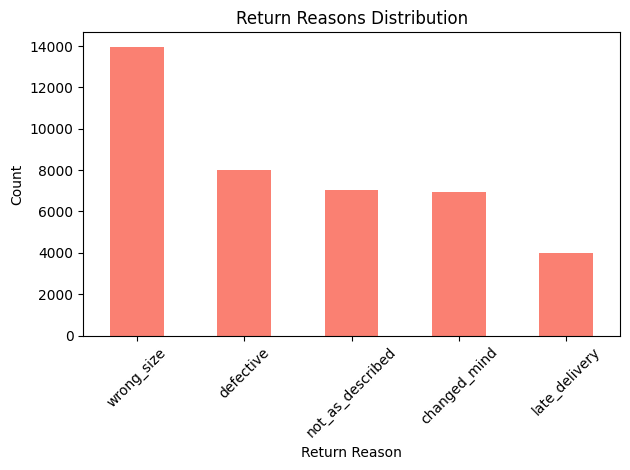

category
Streetwear    21799
Outdoor       14720
GenZ           2126
Casual         1294
Name: count, dtype: int64


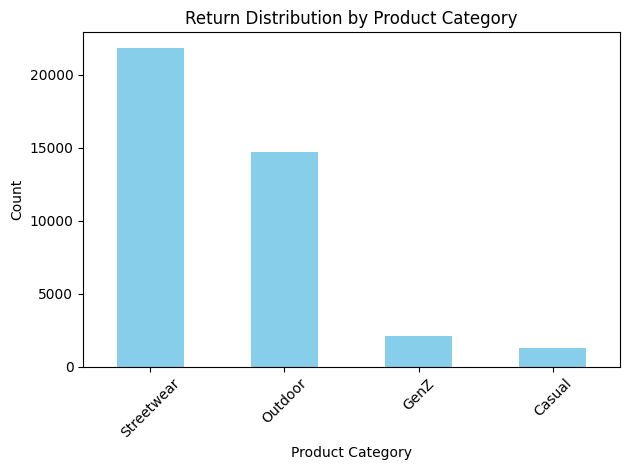

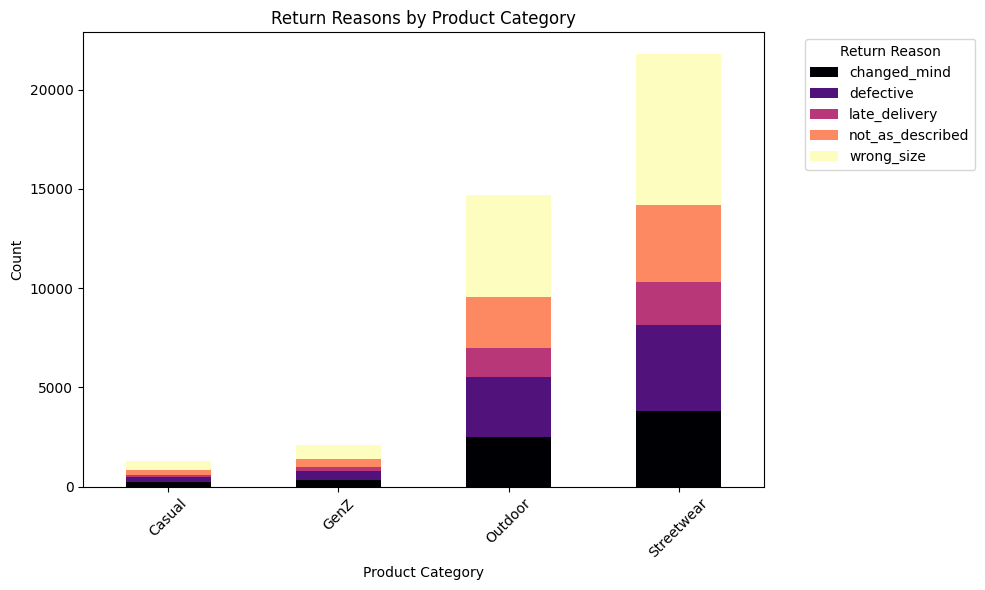

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Load the dataset
products = pd.read_csv("../data/processed/products.csv")
returns = pd.read_csv("../data/processed/returns.csv")
geography = pd.read_csv("../data/processed/geography.csv")
orders = pd.read_csv("../data/processed/orders.csv")
#Merging
return_master = returns.merge(products, on='product_id').merge(orders, on='order_id').merge(geography, on='zip')
return_master.head(10)
#Calculate return rate by return_reason
return_reason_count = return_master['return_reason'].value_counts()
print(return_reason_count)
return_reason_count.plot(kind='bar', color = 'salmon')
plt.title('Return Reasons Distribution')
plt.xlabel('Return Reason')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#insight: size là một vấn đề quan trọng vì gây ra return nhiều nhất
#Calculate return rate by product category
return_category_count = return_master['category'].value_counts()
print(return_category_count)
return_category_count.plot(kind='bar', color = 'skyblue')
plt.title('Return Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#insight: streetwear bị trả về nhiều nhất
#Vậy hiện tượng streetwear bị trả về nhiều nhất có phải do size không? 
return_master.groupby('category')['return_reason'].value_counts().unstack().plot(kind='bar', stacked=True, figsize=(10,6), colormap='magma')
plt.title('Return Reasons by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Return Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
#insight: size là nguyên nhân khiến streetwear bị trả về nhiều nhất
### khoảng 35% là vì size cho mỗi catgory 
#num = return_master.groupby('category')['return_reason'].value_counts()
#rate = num / return_master['category'].value_counts()
#print(rate)
#rate.unstack().plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
#plt.title('Return Rate by Product Category and Return Reason')
#plt.xlabel('Product Category')
#plt.ylabel('Return Rate')
#plt.xticks(rotation=45)
#plt.legend(title='Return Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.tight_layout()
#plt.show()
### 

                        return_count most_common_reason
city        category                                   
Thai Nguyen Streetwear           816         wrong_size
Nam Dinh    Streetwear           806         wrong_size
Son Tay     Streetwear           802         wrong_size
Viet Tri    Streetwear           792         wrong_size
Ninh Binh   Streetwear           774         wrong_size
Bac Giang   Streetwear           773         wrong_size
Ha Long     Streetwear           771         wrong_size
Phu Ly      Streetwear           755         wrong_size
Hai Phong   Streetwear           748         wrong_size
Cam Pha     Streetwear           747         wrong_size


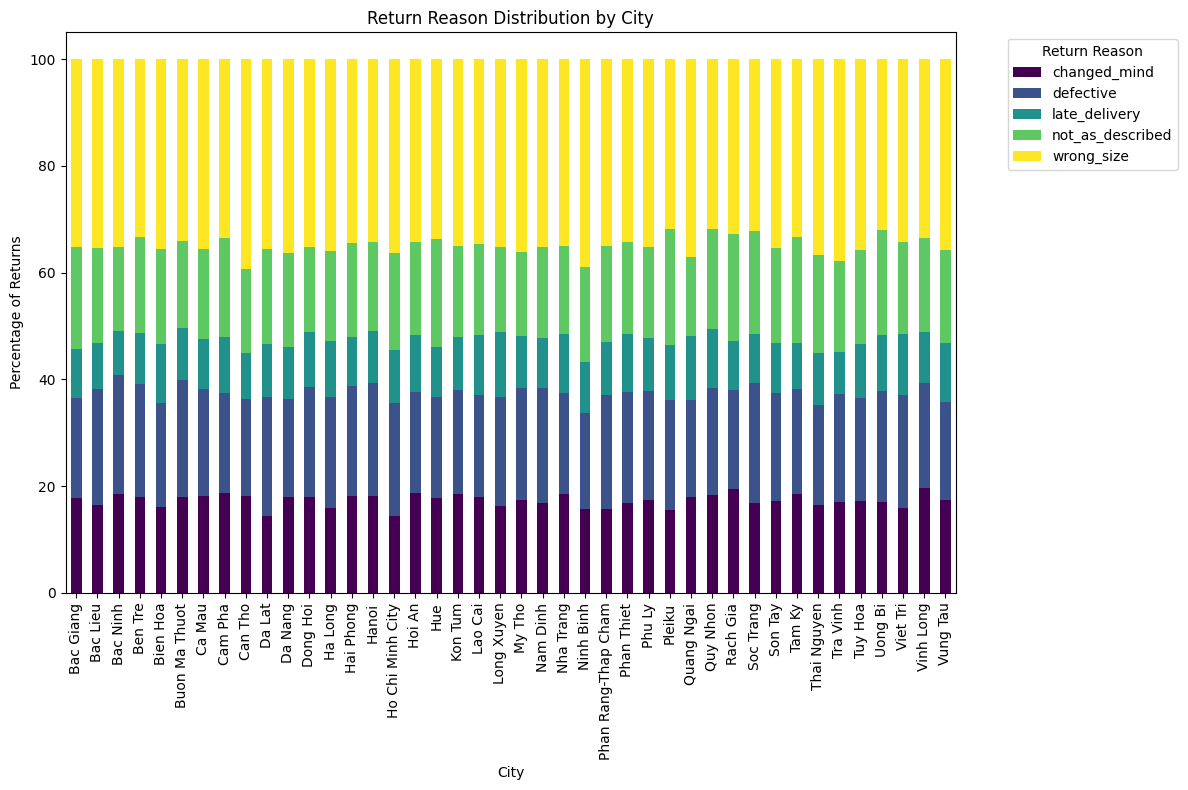


Wrong_Size Hotspots (with Region):
            city    category region  count
99     Ninh Binh  Streetwear   East    300
143  Thai Nguyen  Streetwear   East    291
159     Viet Tri  Streetwear   East    279
135      Son Tay  Streetwear   East    279
91      Nam Dinh  Streetwear   East    278
51       Ha Long  Streetwear   East    269
3      Bac Giang  Streetwear   East    268
31       Cam Pha  Streetwear   East    263
11      Bac Ninh  Streetwear   East    256
111       Phu Ly  Streetwear   East    255


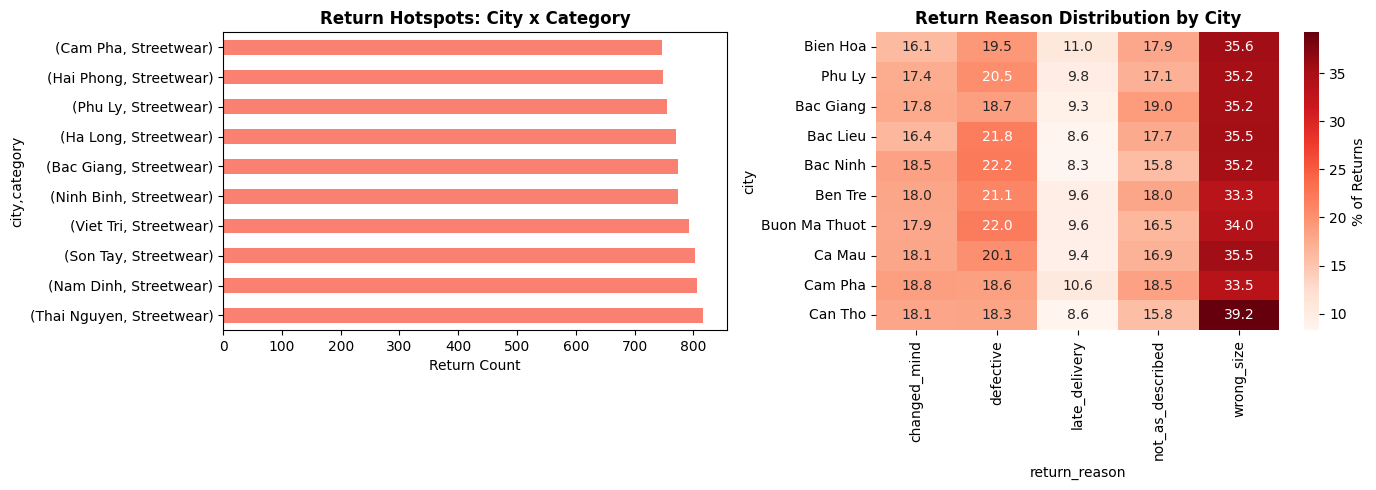

In [47]:
#thử xem với các nơi khác nhau thì category nào bị trả về nhiều nhất với lí do phổ biến nhất là gì, có phải streetwear và wrong_size k
city_distribution = return_master.groupby(['city', 'category']).agg({
    'return_id': 'count',
    'return_reason': lambda x: x.value_counts().index[0]
})
city_distribution.columns = ['return_count', 'most_common_reason']
hotspot = city_distribution.sort_values('return_count', ascending=False).head(10)
print(hotspot)
#pattern này lặp lại ở hầu hết các thành phố
# Return reason distribution by city
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
reason_by_city = pd.crosstab(return_master['city'], return_master['return_reason'])
reason_pct = reason_by_city.div(reason_by_city.sum(axis=1), axis=0) * 100
reason_pct.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='viridis')
plt.title('Return Reason Distribution by City')
plt.xlabel('City')
plt.ylabel('Percentage of Returns') 
plt.xticks(rotation=90)
plt.legend(title='Return Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()  
plt.show()

if 'wrong_size' in return_master['return_reason'].unique():
    wrong_size_hotspot = (
        return_master[return_master['return_reason'] == 'wrong_size']
        .groupby(['city', 'category', 'region'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )
    print("\nWrong_Size Hotspots (with Region):")
    print(wrong_size_hotspot.head(10))

# 4. Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tìm ra những cặp city category mà có số lượng trả hàng cao nhất
hotspot['return_count'].plot(kind='barh', ax=axes[0], color='salmon')
axes[0].set_title('Return Hotspots: City x Category', fontweight='bold')
axes[0].set_xlabel('Return Count')

# Return reason heatmap by city
reason_pct_top = reason_pct.loc[reason_pct.sum(axis=1).nlargest(10).index]
sns.heatmap(reason_pct_top, annot=True, fmt='.1f', cmap='Reds', ax=axes[1], cbar_kws={'label': '% of Returns'})
axes[1].set_title('Return Reason Distribution by City', fontweight='bold')
plt.tight_layout()
plt.show()

# Vấn đề về return hàng chủ yếu là do size và ở streetwear, điều này là phổ biến ở hầu như tất cả các thành phố và nhiều nhất là ở các thành phố phía East, khi đưa vào report có thể sol là tăng cường hướng dẫn chọn size, đặc biệt là với streetwear, và tập trung vào các thành phố phía East để giảm thiểu return hàng.

      category size  return_rate
0       Casual    L     3.198231
1       Casual    M     3.268462
2       Casual    S     3.361184
3       Casual   XL     3.094834
4         GenZ    L     3.144150
5         GenZ    M     3.584183
6         GenZ    S     3.610215
7         GenZ   XL     3.767308
8      Outdoor    L     3.522629
9      Outdoor    M     3.397542
10     Outdoor    S     3.551365
11     Outdoor   XL     3.352107
12  Streetwear    L     3.387608
13  Streetwear    M     3.384817
14  Streetwear    S     3.394993
15  Streetwear   XL     3.361847


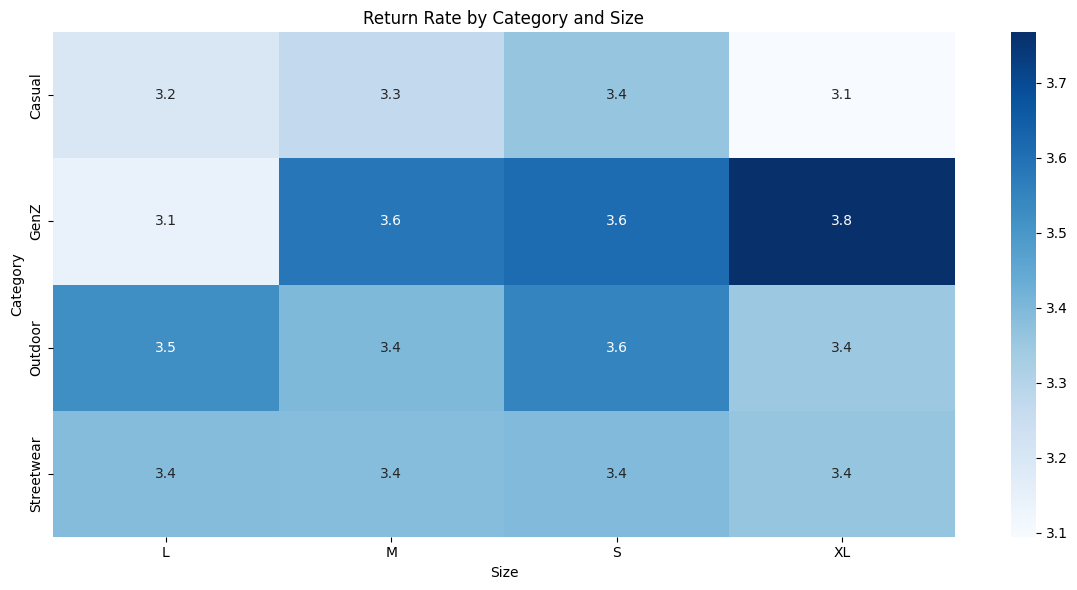

size                L          M          S         XL
category                                              
Casual       0.488201   0.999215   1.123319   0.582191
GenZ         1.109631   1.520267   1.898965   0.826748
Outdoor     10.426514   9.859836   8.127863   8.467322
Streetwear  12.329130  12.196813  13.302794  16.741190


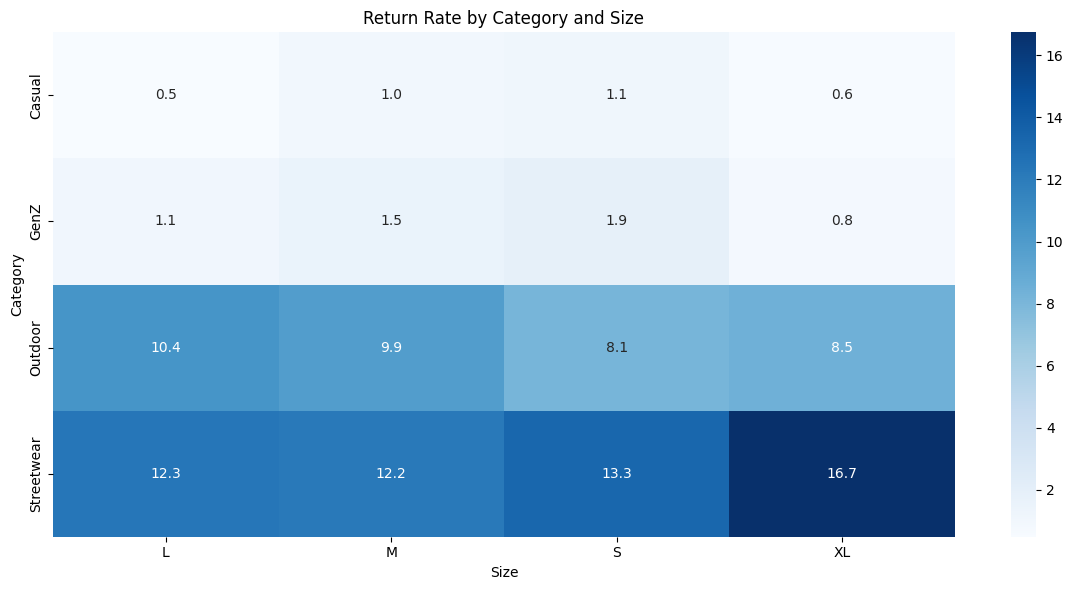

In [96]:
#tính return rate theo category và size, công thức = return/total_order(tức là trả về/bán ra)
order_items = pd.read_csv("../data/processed/order_items.csv")
returns_with_size = returns.merge(products, on='product_id', how='left')
returns_with_size.head()
whole_order = order_items.merge(products, on='product_id', how='left')
return_by_catnsize = returns_with_size.groupby(['category', 'size'])['return_quantity'].sum()
return_total = whole_order.groupby(['category', 'size'])['quantity'].sum()
return_rate = (return_by_catnsize / return_total * 100).reset_index(name='return_rate')
print(return_rate)
plt.figure(figsize=(12, 6))
sns.heatmap(return_rate.pivot(index='category', columns='size', values='return_rate'), annot=True, fmt='.1f', cmap='Blues')
plt.title('Return Rate by Category and Size')
plt.xlabel('Size')
plt.ylabel('Category')
plt.tight_layout()
plt.show()
# genZ trả hàng size XL, M, L nhiều nhất
# thử tính trên những đơn return thôi 
rate = (
    return_by_catnsize 
    / returns_with_size['return_quantity'].sum()
    * 100
).unstack(fill_value=0)
print(rate)
plt.figure(figsize=(12, 6))
sns.heatmap(rate, annot=True, fmt='.1f', cmap='Blues')
plt.title('Return Rate by Category and Size')
plt.xlabel('Size')
plt.ylabel('Category')
plt.tight_layout()
plt.show()
# Đối với những người mua hàng của category genZ, có 3,8% trả size XL -> suy ra có thể do size XL không phù hợp với genZ nên họ trả về nhiều hơn, tương tự với size M và L cũng vậy nhưng không nhiều bằng size XL. 
# Trong các đơn hàng bị trả lại, streetwear size XL có rate cao nhất, vì nó bán được nhiều nhưng trả về cũng nhiều -> có thể gây ảnh hưởng đến chi phí vận hành, cụ thể liên quan đến tiền hoàn

category    return_reason   
Casual      changed_mind        0.575980
            defective           0.674613
            late_delivery       0.317301
            not_as_described    0.531316
            wrong_size          1.156613
GenZ        changed_mind        0.556195
            defective           0.701237
            late_delivery       0.385381
            not_as_described    0.617328
            wrong_size          1.257432
Outdoor     changed_mind        0.604359
            defective           0.713761
            late_delivery       0.339915
            not_as_described    0.603504
            wrong_size          1.192906
Streetwear  changed_mind        0.595084
            defective           0.679999
            late_delivery       0.328297
            not_as_described    0.604695
            wrong_size          1.172755
dtype: float64
category    return_reason   
Casual      changed_mind        17.690769
            defective           20.720206
            late_delive

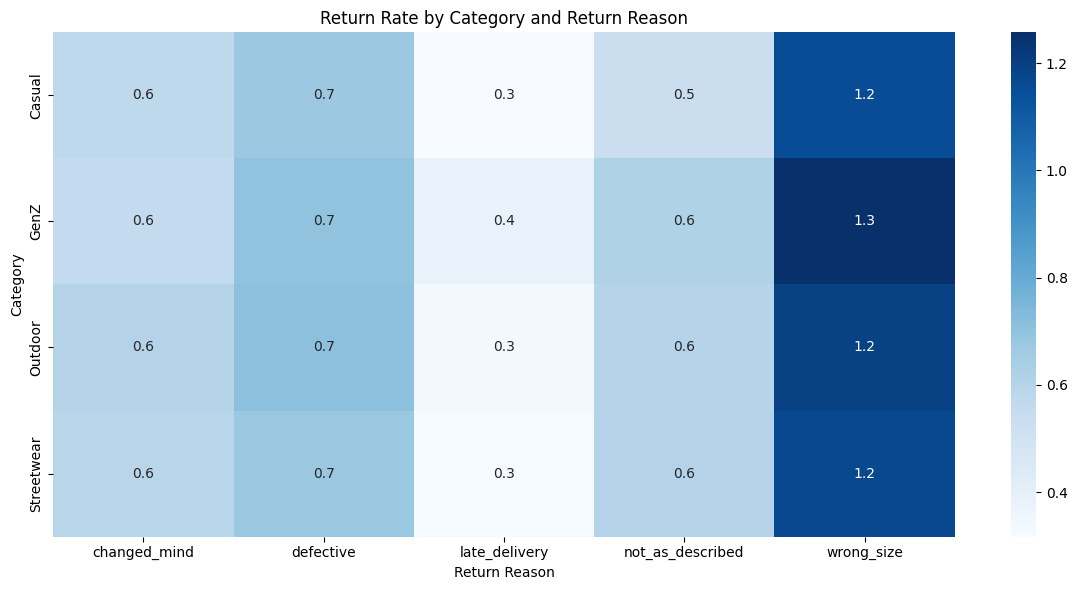

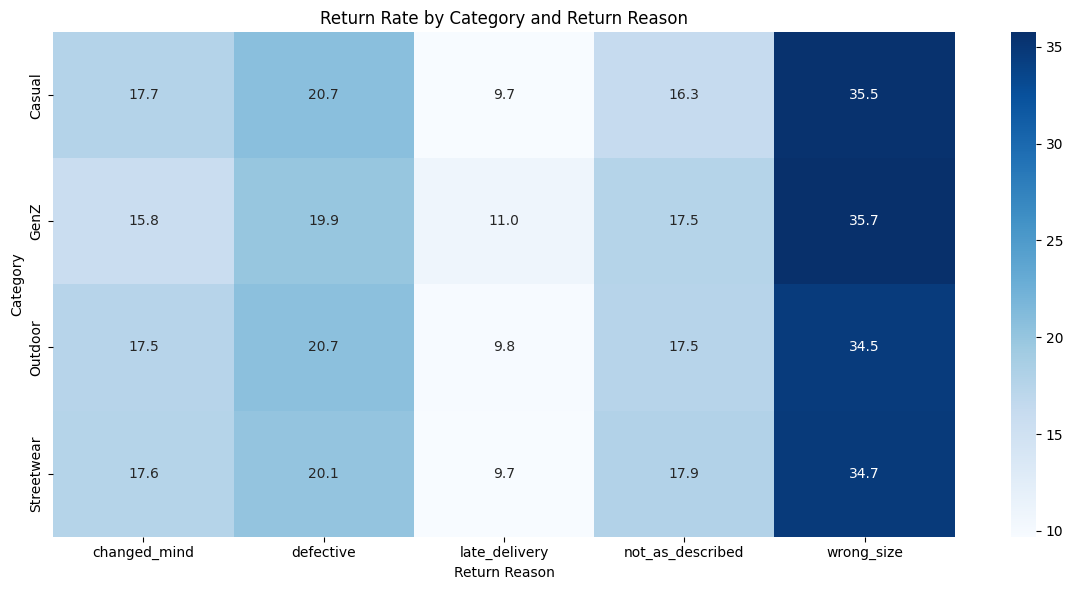

In [97]:
# tính return rate theo category và reason 
returns = pd.read_csv("../data/processed/returns.csv")
products = pd.read_csv("../data/processed/products.csv")
order_items = pd.read_csv("../data/processed/order_items.csv")

return_cate = returns.merge(products, on='product_id', how='left')
num = return_cate.groupby(['category','return_reason'])['return_quantity'].sum()
denom = order_items.merge(products, on='product_id', how='left').groupby(['category'])['quantity'].sum()
denom_2 = return_cate.groupby('category')['return_quantity'].sum() 
rate = num / denom * 100
rate2 = num / denom_2 * 100
print(rate)
print(rate2)
plt.figure(figsize=(12, 6))
sns.heatmap(rate.unstack(fill_value=0), annot=True, fmt='.1f', cmap='Blues')
plt.title('Return Rate by Category and Return Reason')
plt.xlabel('Return Reason')
plt.ylabel('Category')
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 6))
sns.heatmap(rate2.unstack(fill_value=0), annot=True, fmt='.1f', cmap='Blues')
plt.title('Return Rate by Category and Return Reason')
plt.xlabel('Return Reason')
plt.ylabel('Category')
plt.tight_layout()
plt.show()
#rate là tính trên toàn bộ sp, rate2 là tính trên những sp bị trả về
#Chủ yếu vẫn là wrong size thôi, phân bố khá đồng đều với genZ rate cao nhất

size
L     3.427695
M     3.396692
S     3.460053
XL    3.363634
dtype: float64
size
L     24.353476
M     24.576132
S     24.452941
XL    26.617451
Name: return_quantity, dtype: float64


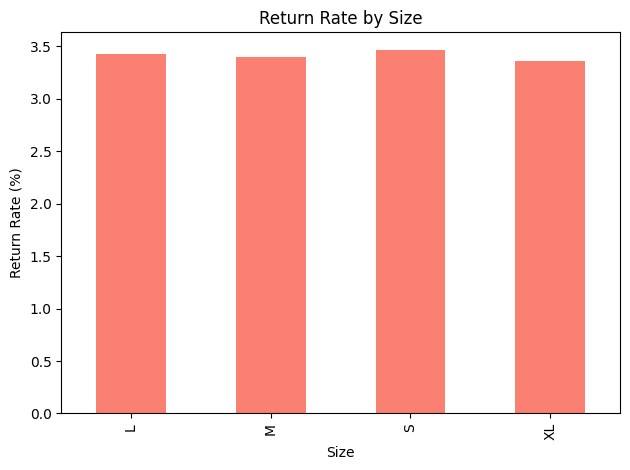

In [98]:
# tính return rate theo size
returns = pd.read_csv("../data/processed/returns.csv")
products = pd.read_csv("../data/processed/products.csv")
order_items = pd.read_csv("../data/processed/order_items.csv")

return_size = returns.merge(products, on='product_id', how='left')
num = return_size.groupby('size')['return_quantity'].sum()
denom = order_items.merge(products, on='product_id', how='left').groupby(['size'])['quantity'].sum()
denom_2 = return_size['return_quantity'].sum() 
rate = num / denom * 100
rate2 = num / denom_2 * 100
print(rate)
print(rate2)
barplot = rate.plot(kind='bar', color='salmon')
plt.title('Return Rate by Size')
plt.xlabel('Size')  
plt.ylabel('Return Rate (%)')
plt.tight_layout()
plt.show()
#nothing significant

       customer_id  first_order_date
0                1              2012
1                2              2013
2                3              2012
3                4              2020
4                5              2012
...            ...               ...
90241       157554              2022
90242       157555              2015
90243       157557              2017
90244       157561              2012
90245       157563              2012

[90246 rows x 2 columns]
        order_id order_date  customer_id    zip order_status payment_method  \
0              1 2012-07-04        58578   1109    delivered    credit_card   
1              2 2012-07-04        58621   1330     returned            cod   
2              3 2012-07-04        58811   1473    delivered    credit_card   
3              4 2012-07-04        59453   2360    delivered    credit_card   
4              6 2012-07-06        57821   2886    delivered         paypal   
...          ...        ...          ...    ...         

       customer_id  first_order_date
0                1              2012
1                2              2013
2                3              2012
3                4              2020
4                5              2012
...            ...               ...
90241       157554              2022
90242       157555              2015
90243       157557              2017
90244       157561              2012
90245       157563              2012

[90246 rows x 2 columns]
        order_id order_date  customer_id    zip order_status payment_method  \
0              1 2012-07-04        58578   1109    delivered    credit_card   
1              2 2012-07-04        58621   1330     returned            cod   
2              3 2012-07-04        58811   1473    delivered    credit_card   
3              4 2012-07-04        59453   2360    delivered    credit_card   
4              6 2012-07-06        57821   2886    delivered         paypal   
...          ...        ...          ...    ...         

<Figure size 1200x600 with 0 Axes>

       customer_id  first_order_date
0                1              2012
1                2              2013
2                3              2012
3                4              2020
4                5              2012
...            ...               ...
90241       157554              2022
90242       157555              2015
90243       157557              2017
90244       157561              2012
90245       157563              2012

[90246 rows x 2 columns]
        order_id order_date  customer_id    zip order_status payment_method  \
0              1 2012-07-04        58578   1109    delivered    credit_card   
1              2 2012-07-04        58621   1330     returned            cod   
2              3 2012-07-04        58811   1473    delivered    credit_card   
3              4 2012-07-04        59453   2360    delivered    credit_card   
4              6 2012-07-06        57821   2886    delivered         paypal   
...          ...        ...          ...    ...         

<Figure size 1200x600 with 0 Axes>

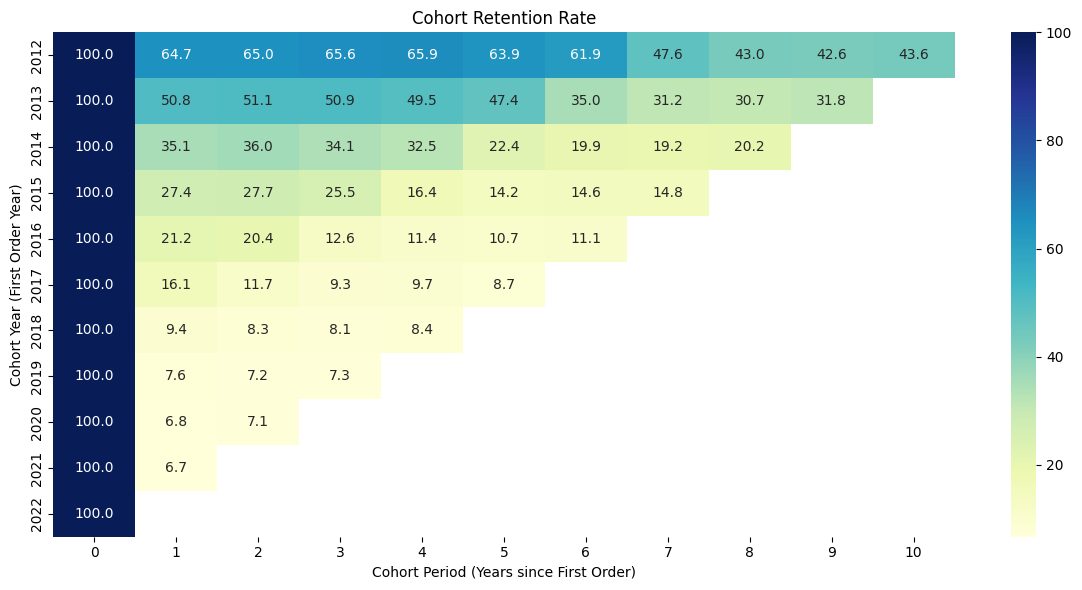

In [5]:
#Cohort retention analysis
orders = pd.read_csv("../data/processed/orders.csv")
orders['order_date'] = pd.to_datetime(orders['order_date'])
#tính năm đặt đơn đầu tiên cho mỗi kh
first_order = (
    orders.groupby("customer_id", as_index=False)["order_date"]
    .min()
    .rename(columns={"order_date": "first_order_date"})
)
first_order['first_order_date'] = first_order['first_order_date'].dt.year
print(first_order) 
#tính khoảng thời gian giữa các lần mua hàng của khách hàng
cohort = orders.merge(first_order, on='customer_id')
print(cohort)
cohort['order_date'] = cohort['order_date'].dt.year
cohort['cohort_period'] = cohort['order_date'] - cohort['first_order_date']
print(cohort) 
#tính kích thước của mỗi cohort
cohort_size = first_order.groupby('first_order_date').size().rename('cohort_size')
print(cohort_size)   
retention_counts = cohort.groupby(['first_order_date', 'cohort_period'])['customer_id'].nunique().rename('retention_count').reset_index()
print(retention_counts.head(20))
#tính retention rate = retention_count / cohort_size
retention_rate = retention_counts.merge(cohort_size, on='first_order_date')
retention_rate['retention_rate'] = retention_rate['retention_count'] / retention_rate['cohort_size'] * 100
print(retention_rate.head(20))
#visualize retention rate
retention_pivot = retention_rate.pivot(index='first_order_date', columns='cohort_period', values='retention_rate')
plt.figure(figsize=(12, 6))
plt.figure(figsize=(12, 6))
sns.heatmap(retention_pivot, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Cohort Retention Rate')
plt.xlabel('Cohort Period (Years since First Order)')
plt.ylabel('Cohort Year (First Order Year)')
plt.tight_layout()
plt.show()
#insight: các cohort 2012 và 2013 có retention rate cao và lâu dài hơn, càng về các cohort sau retention rate càng thấp
#Từ cohort 2016 là hầu như sau period 1 là giảm khá sâu
#Từ cohort 2019 trở đi thì retention rate rất thấp ngay từ period 1, insight này có thể cần được nghiên cứu sâu hơn để ra lí do

   order_id order_date  customer_id   zip order_status payment_method_x  \
0         1 2012-07-04        58578  1109    delivered      credit_card   
1         2 2012-07-04        58621  1330     returned              cod   
2         3 2012-07-04        58811  1473    delivered      credit_card   
3         4 2012-07-04        59453  2360    delivered      credit_card   
4         6 2012-07-06        57821  2886    delivered           paypal   

  device_type    order_source payment_method_y  payment_value  installments  
0     desktop     paid_search      credit_card        7967.54             3  
1      mobile     paid_search              cod       71163.75             1  
2     desktop          direct      credit_card       33660.99             3  
3     desktop        referral      credit_card       53196.25             3  
4      mobile  email_campaign           paypal        1597.84             1  
            last_order_date  frequency   monetary  recency  R_rank  F_rank  \
cus

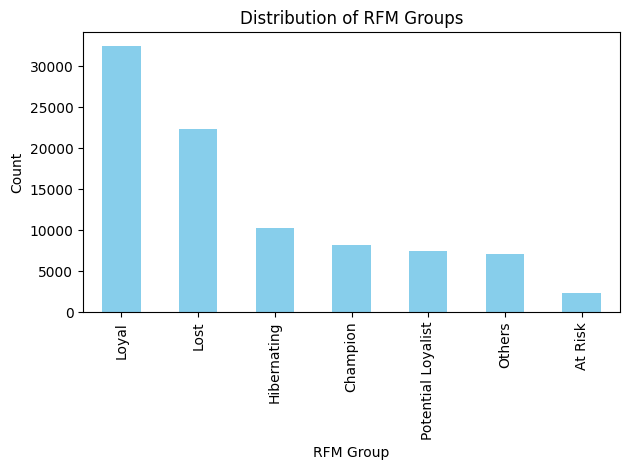

RFM_group
At Risk                3.374519
Champion              31.709583
Hibernating            4.936499
Lost                   3.134517
Loyal                 52.003073
Others                 2.101217
Potential Loyalist     2.740592
Name: monetary, dtype: float64


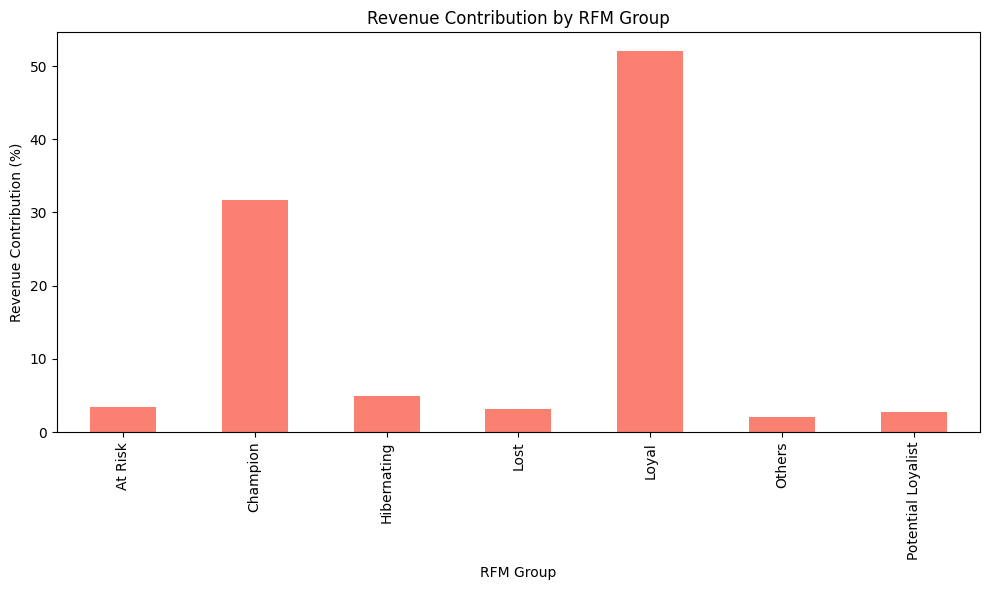

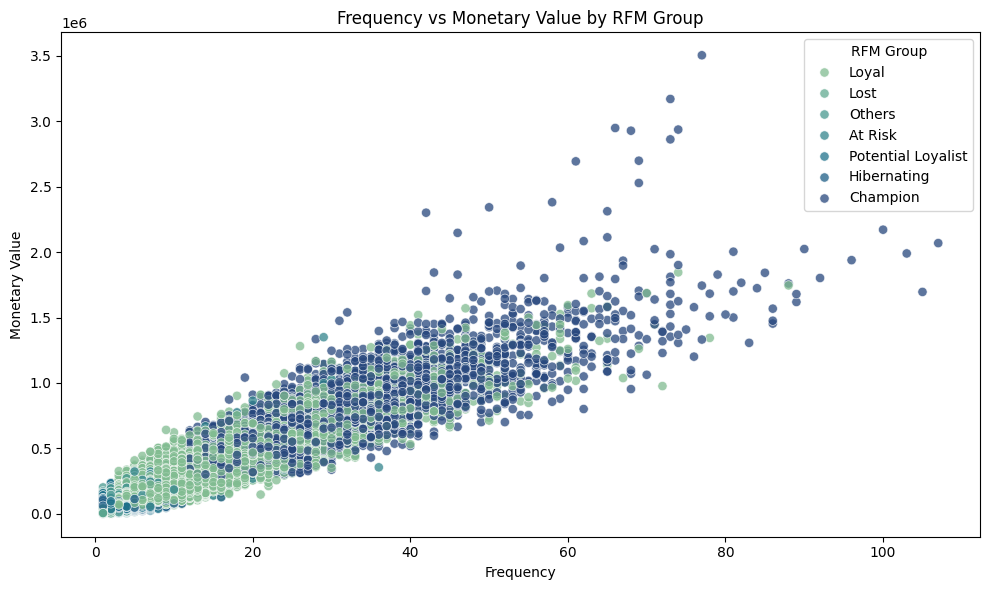

            last_order_date  frequency   monetary  recency  R_rank  F_rank  \
customer_id                                                                  
4                2020-06-28          1   10939.06      916       3       1   
9                2019-06-05          1   15926.52     1305       3       1   
11               2017-05-15          4  221384.76     2056       2       3   
12               2021-04-17          1   13636.55      623       4       1   
44               2017-05-30          4  202132.29     2041       2       3   
52               2016-10-10          5  164003.57     2273       1       3   
88               2019-06-12          1   83340.80     1298       3       1   
106              2019-06-10          1   29824.76     1300       3       1   
125              2020-11-09          1    7972.26      782       3       1   
136              2019-05-01          1   23423.96     1340       3       1   
146              2022-10-31          1   39624.08       61      

In [ ]:
# RFM analysis(Recency, Frequency, Monetary)
payments = pd.read_csv("../data/processed/payments.csv")
rfm = orders.merge(payments, on='order_id')
print(rfm.head())
rfm = rfm.groupby('customer_id').agg(
    last_order_date=('order_date', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
)
rfm['recency'] = (pd.to_datetime('2022-12-31') - rfm['last_order_date']).dt.days
#ranking customers into quartiles, với recency thì càng nhỏ càng tốt nên rank ngược lại, còn frequency và monetary thì càng lớn càng tốt nên rank bình thường
rfm['R_rank'] = pd.qcut(rfm['recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_rank'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_rank'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
print(rfm.head(20))
#Chia customers thành 4 nhóm dựa trên RFM score
#Champion: R cao, F cao, M cao
# Chia customers thành nhiều nhóm hơn dựa trên RFM score
# Champion: mua gần đây, mua nhiều, chi tiêu cao
# Loyal: mua đều, giá trị ổn
# Potential Loyalist: mua gần đây, có tiềm năng quay trở lại mua tiếp
# New Customers: mới mua gần đây nhưng tần suất còn thấp
# At Risk: trước đây mua tốt nhưng gần đây lâu không quay lại
# Hibernating: ít mua, mức độ gắn kết thấp
# Lost: rất lâu không mua và giá trị thấp
def rfm_group(row):
    if row['R_rank'] >= 5 and row['F_rank'] >= 5 and row['M_rank'] >= 5:
        return 'Champion'
    elif row['R_rank'] >= 3 and row['F_rank'] >= 3 and row['M_rank'] >= 3:
        return 'Loyal'
    elif row['R_rank'] >= 3 and row['F_rank'] >= 2 and row['M_rank'] >= 2:
        return 'Potential Loyalist'
    elif row['R_rank'] <= 2 and row['F_rank'] >= 4 and row['M_rank'] >= 4:
        return 'At Risk'
    elif row['R_rank'] <= 2 and row['F_rank'] <= 2 and row['M_rank'] <= 2:
        return 'Lost'
    elif row['R_rank'] <= 2 and row['M_rank'] <= 3:
        return 'Hibernating'
    else :
        return 'Others'

rfm['RFM_group'] = rfm.apply(rfm_group, axis=1)
#visualize distribution of RFM groups
rfm['RFM_group'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of RFM Groups')
plt.xlabel('RFM Group')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
#% revenue contribution by RFM group
revenue_contribution = rfm.groupby('RFM_group')['monetary'].sum() / rfm['monetary'].sum() * 100
print(revenue_contribution)
plt.figure(figsize=(10, 6))
revenue_contribution.plot(kind='bar', color='salmon')
plt.title('Revenue Contribution by RFM Group')
plt.xlabel('RFM Group')
plt.ylabel('Revenue Contribution (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
#insight: Loyal là đông nhất và đóng góp đến 50% doanh thu, là nhóm khách cần được ưu tiên cốt lõi, cần theo dõi sự hài lòng để duy trì lợi nhuận 
#Champion là nhóm khách khá ít nhưng đóng góp đến 30% doanh thu, đây là nhóm khách hàng có giá trị cao, sẵn sàng chi tiền, có thể phát triển những chương trình, gói lợi nhuận VIP, độc quyền... để tối đa hóa trải nghiệm của họ và lợi nhuận
#Ko nên đầu tư vào chiến lược marketing quá nhiều cho nhóm Lost hay at risk vì contribution của họ rất thấp dù nhóm lost khá nhiều khách hàng, maybe có thể có những chiến lược win back đơn giản như email nhắc nhở, ưu đãi nhỏ để kích thích họ quay lại nhưng không nên đầu tư quá nhiều nguồn lực vào nhóm này
#Hibernating là nhóm trung bình và có thể có tiềm năng để chuyển đổi thành Loyal hoặc Champion nếu có chiến lược chăm sóc phù hợp
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='frequency', y='monetary', hue='RFM_group', palette='crest',alpha=0.75,s=45)
plt.title('Frequency vs Monetary Value by RFM Group')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='RFM Group')
plt.tight_layout()
plt.show()
pd.set_option('display.max_rows', None)